# Deep Learning
## Lab Assignment 4 - Naive Bayes Classifier
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title:
Write a program to implement the Naïve Bayesian classifier for a sample training data set stored
as a .CSV file. Compute the accuracy of the classifier, considering few test data sets.

# Multinomial Naive Bayes Classifier

## Load Dataset


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Social Media Sentiment Analysis Dataset.csv')

# Display the first 5 rows
print("First 5 rows of the DataFrame:")
print(df.head())

# Print column names and their data types
print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                    

## Preprocess Text Data

In [ ]:
text_column = 'Text'      # change if different
label_column = 'Sentiment'    # change if different

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    return text.strip()

df[text_column] = df[text_column].apply(clean_text)

# Remove empty rows
df = df[df[text_column] != ""]


## Encode Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

print(f"\nUnique values in '{label_column}' before encoding:")
print(df[label_column].value_counts())

def map_sentiment(sentiment):
    sentiment = str(sentiment).lower()
    if 'positive' in sentiment or 'joy' in sentiment or 'excitement' in sentiment or 'happy' in sentiment or 'love' in sentiment or 'good' in sentiment or 'optimism' in sentiment or 'enthusiasm' in sentiment or 'amusement' in sentiment or 'vibrancy' in sentiment or 'thrilling' in sentiment or 'mesmerizing' in sentiment or 'delight' in sentiment or 'bliss' in sentiment or 'wonder' in sentiment:
        return 'Positive'
    elif 'negative' in sentiment or 'sad' in sentiment or 'anger' in sentiment or 'fear' in sentiment or 'disappointment' in sentiment or 'frustration' in sentiment or 'bad' in sentiment or 'stress' in sentiment or 'anxiety' in sentiment or 'terrible' in sentiment or 'exhaustion' in sentiment or 'regret' in sentiment or 'grief' in sentiment or 'melancholy' in sentiment or 'dread' in sentiment:
        return 'Negative'
    else:
        return 'Neutral'

df[label_column] = df[label_column].apply(map_sentiment)

print(f"\nUnique values in '{label_column}' after mapping:")
print(df[label_column].value_counts())

le = LabelEncoder()
df[label_column] = le.fit_transform(df[label_column])


Unique values in 'Sentiment' before encoding:
Sentiment
Neutral     502
Positive    170
Negative     60
Name: count, dtype: int64

Unique values in 'Sentiment' after mapping:
Sentiment
Neutral     502
Positive    170
Negative     60
Name: count, dtype: int64


## Convert Text to Numeric

In [ ]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df[text_column])
y = df[label_column]

## Split Data


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (585, 2300)
Shape of X_test: (147, 2300)
Shape of y_train: (585,)
Shape of y_test: (147,)


## Train Multinomial Naïve Bayes Classifier


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

print("Multinomial Naive Bayes classifier trained successfully.")

Multinomial Naive Bayes classifier trained successfully.


## Predict and Evaluate Accuracy

Model Accuracy: 0.6939

Classification Report:

              precision    recall  f1-score   support

           0       0.45      0.69      0.55        13
           1       0.84      0.68      0.75        96
           2       0.56      0.74      0.64        38

    accuracy                           0.69       147
   macro avg       0.62      0.70      0.64       147
weighted avg       0.74      0.69      0.70       147


Confusion Matrix:

[[ 9  3  1]
 [10 65 21]
 [ 1  9 28]]





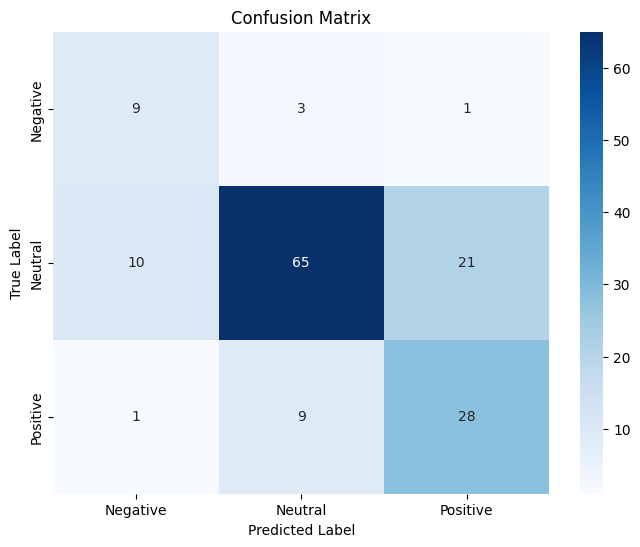

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Predict the sentiment labels on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))
print("\n\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Get the class names from the LabelEncoder
class_names = le.classes_

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Gaussian Naive Bayes Classifier

## Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("Cybersecurity Intrusion Dataset.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox        

## Preprocess Data

In [ ]:
df = df.dropna()

# Separate Features & Target
X = df.drop(columns=['session_id', df.columns[-1]]) # Drop session_id and the target column
y = df.iloc[:, -1]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y)

# Identify categorical columns in X
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

## Feature Scaling

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (6056, 13)
Shape of X_test: (1515, 13)
Shape of y_train: (6056,)
Shape of y_test: (1515,)


## Train Gaussian Naive Bayes Classifier

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

## Predict & Evaluate


Model Accuracy: 0.834983498349835

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       841
           1       0.91      0.70      0.79       674

    accuracy                           0.83      1515
   macro avg       0.85      0.82      0.83      1515
weighted avg       0.85      0.83      0.83      1515



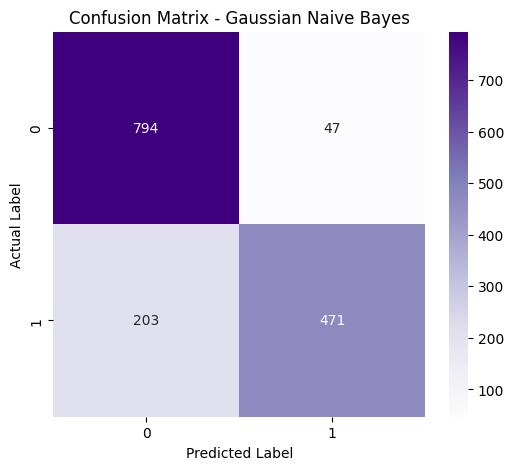

In [ ]:
# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()